In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv(r"D:\Projects\Fda\data\Processed Data\food_delivery_cleaned.csv")
df.head()

,Age,Rating,Weather_conditions,Traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),distance,Preparation_Time,Delivery_Time
0,36.0,4.2,Fog,3,2,Snack,motorcycle,3.0,0,Metropolitian,46,10.280582,15.0,31.0
1,21.0,4.7,Stormy,2,1,Meal,motorcycle,1.0,0,Metropolitian,23,6.242319,10.0,13.0
2,23.0,4.7,Sandstorms,1,1,Drinks,scooter,1.0,0,Metropolitian,21,13.787860,10.0,11.0
3,34.0,4.3,Sandstorms,0,0,Buffet,motorcycle,0.0,0,Metropolitian,20,2.930258,10.0,10.0
4,24.0,4.7,Fog,3,1,Snack,scooter,1.0,0,Metropolitian,41,19.396618,15.0,26.0


Defining Late Delivery

In [6]:
df['late_delivery_time'] = df['Time_taken (min)'] > 30
print(df['late_delivery_time'].value_counts())

late_delivery_time
False    30773
True     13080
Name: count, dtype: int64


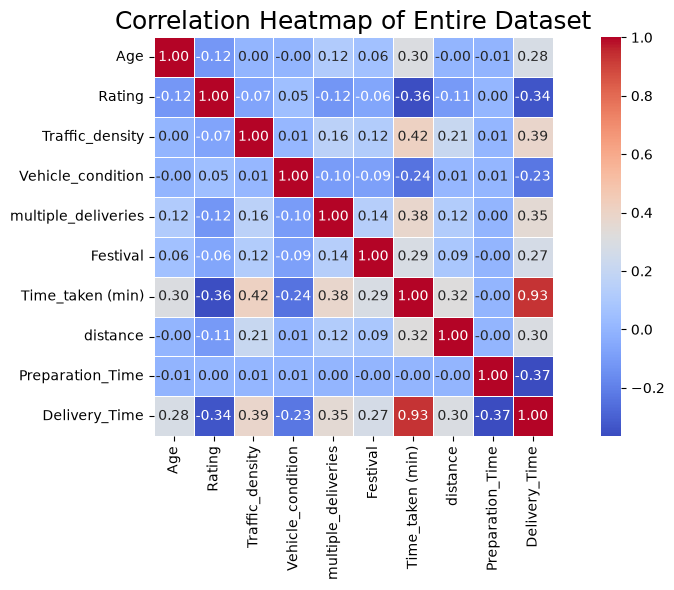

In [9]:
numeric_df = df.select_dtypes(include=['number'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar=True
)

plt.title("Correlation Heatmap of Entire Dataset", fontsize=18)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

Checking Correlation between attributes

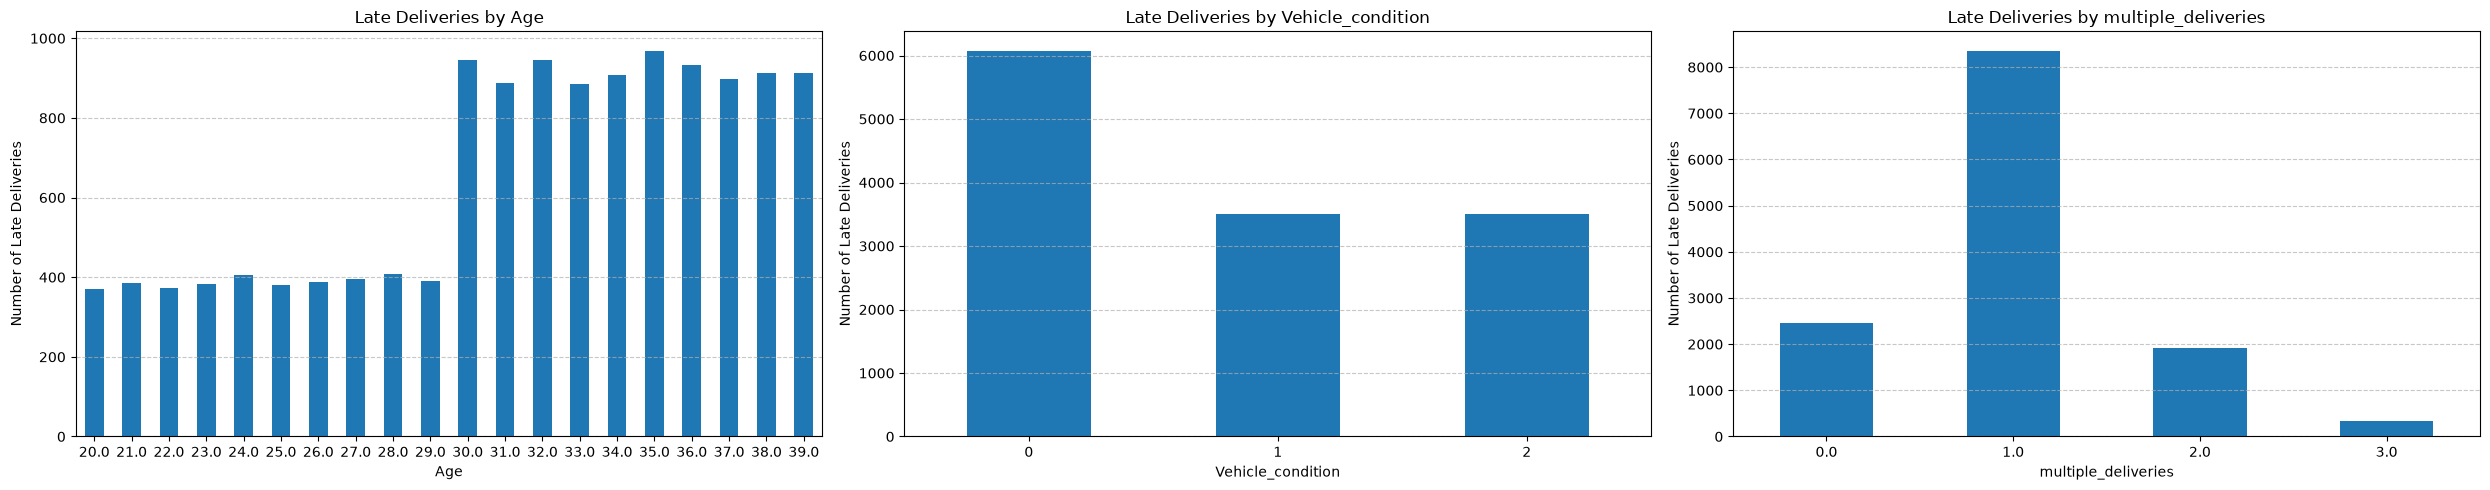

In [11]:
# Filter only late deliveries
late_deliveries = df[df['late_delivery_time'] == 1]

# Columns to analyze
columns = ['Age', 'Vehicle_condition', 'multiple_deliveries']

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(25, 5))

for ax, col in zip(axes, columns):
    counts = late_deliveries[col].value_counts().sort_index()

    counts.plot(kind='bar', ax=ax)

    ax.set_title(f'Late Deliveries by {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Number of Late Deliveries')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [13]:
bins = [18, 25, 30, 35, 40, 50]
labels = ['18-24', '25-29', '30-34', '35-39', '40+']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)

# List of features to analyze
features = [
    'Age_Group',
    'Vehicle_condition',
    'multiple_deliveries'
]

# Analyze each feature
for feature in features:
    print(f"\n{'='*60}")
    print(f"Late Delivery Analysis: {feature}")
    print('='*60)

    analysis = (
        df.groupby(feature)
          .agg(
              Total_Deliveries=('late_delivery_time', 'count'),
              Late_Deliveries=('late_delivery_time', 'sum')
          )
    )

    analysis['Late_Rate (%)'] = (
        analysis['Late_Deliveries'] /
        analysis['Total_Deliveries'] * 100
    ).round(2)

    # Sort by late rate (highest first)
    analysis = analysis.sort_values('Late_Rate (%)', ascending=False)

    print(analysis)


Late Delivery Analysis: Age_Group
           Total_Deliveries  Late_Deliveries  Late_Rate (%)
Age_Group                                                  
30-34                 10933             4596          42.04
35-39                  8848             3657          41.33
25-29                 11119             2528          22.74
18-24                 12953             2299          17.75
40+                       0                0            NaN

Late Delivery Analysis: Vehicle_condition
                   Total_Deliveries  Late_Deliveries  Late_Rate (%)
Vehicle_condition                                                  
0                             14599             6077          41.63
2                             14639             3505          23.94
1                             14615             3498          23.93

Late Delivery Analysis: multiple_deliveries
                     Total_Deliveries  Late_Deliveries  Late_Rate (%)
multiple_deliveries                            

C:\Users\pawan\AppData\Local\Temp\ipykernel_532\3320813906.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(feature)
